# LiH ground-state energy with Sample-Based Quantum Diagonalization (SQD) — plus a VQE comparison

**Pipeline:** Molecule → trial circuit → measured configurations → selected subspace → classical diagonalization → energy.

| Step | What we do |
|---|---|
| 0 | Install & imports |
| 1 | Define the chemistry problem (LiH / STO-3G, frozen core, 2e in 5 orbitals), HF + exact references |
| 2 | Trial circuit (UCCSD seeded with **classical CCSD amplitudes**, no optimisation) and finite-shot sampling |
| 3 | SQD: bitstrings → alpha/beta configurations → projected Hamiltonian → lowest eigenvalue |
| 4 | Accuracy vs bond length (SQD vs random-configuration baseline vs HF vs exact) |
| 5 | Budget study: error vs shots and vs retained subspace size, repeated over seeds |
| 6 | VQE (optional comparison) with transparent cost accounting |
| 7 | Controlled design test: *which circuit supplies the configurations?* (CCSD-seeded vs VQE-trained vs random-angle) |
| 8 | Cost ledger and conclusions |

All energies are **total energies in hartree (Ha)**; errors are in **millihartree (mHa)** relative to the exact energy of the *same* finite Hamiltonian and particle sector (not an experimental energy).

## Step 0 — Setup (Colab)

In [1]:
!pip install -q qiskit qiskit-aer qiskit-addon-sqd qiskit-nature pyscf scipy matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.5 MB/s eta 0:00:00


In [2]:
import time, warnings, itertools
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply
from scipy.optimize import minimize
from importlib.metadata import version
warnings.filterwarnings("ignore")

from pyscf import gto, scf, mcscf, ao2mo, fci, cc
from qiskit import transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_addon_sqd.fermion import solve_fermion

for p in ["qiskit","qiskit-aer","qiskit-addon-sqd","qiskit-nature","pyscf","numpy","scipy"]:
    print(f"{p:18s}{version(p)}")

MHA = 1e3          # hartree -> millihartree
LEDGER = []        # every quantum/classical cost is logged here (Step 8)
def log(stage, **kw): LEDGER.append(dict(stage=stage, **kw))

qiskit            2.5.2
qiskit-aer        0.17.2
qiskit-addon-sqd  0.13.1
qiskit-nature     0.8.0
pyscf             2.14.0
numpy             2.1.3
scipy             1.16.3


## Step 1 — The chemistry problem

### Physics behind it
* **Born–Oppenheimer:** nuclei are fixed point charges; we solve only the electronic Schrödinger equation $H_{el}\Psi=E\Psi$ and add the classical nuclear repulsion $E_{nn}$ at the end.
* **Second quantization:** in a finite orbital basis,
  $$H=E_{\rm core}+\sum_{pq,\sigma}h_{pq}\,a^\dagger_{p\sigma}a_{q\sigma}+\tfrac12\sum_{pqrs,\sigma\tau}(pq|rs)\,a^\dagger_{p\sigma}a^\dagger_{r\tau}a_{s\tau}a_{q\sigma}.$$
  Here $h_{pq}$ are one-electron integrals (kinetic + electron–nucleus) and $(pq|rs)$ are two-electron repulsion integrals.
* **Hartree–Fock (HF):** the best *single* Slater determinant. It misses **electron correlation**: the energy gap HF→exact is the "correlation energy", which grows when the bond is stretched.
* **STO-3G LiH:** 6 spatial orbitals (Li 1s,2s,2p×3; H 1s), 4 electrons. **Frozen core:** the lowest (essentially Li 1s) orbital stays doubly occupied; its energy and its mean-field effect on the rest are folded into the constant $E_{\rm core}$ (= nuclear repulsion + frozen-core energy) and into $h_{pq}$. This leaves **2 electrons in 5 spatial orbitals** = 10 spin orbitals = **10 qubits**.
* **Configurations (determinants):** which spin orbitals are occupied. With one α and one β electron in 5 orbitals there are $5\times5=25$ determinants. SQD works in a subspace of these.
* **Mapping / bit ordering (important):** Jordan–Wigner, occupation encoding, qubit $k<5$ = α spatial orbital $k$, qubit $5+k$ = β orbital $k$. A Qiskit bitstring is printed with qubit 0 on the right, so it reads **`[β4…β0][α4…α0]`**: the left 5 characters are β, the right 5 are α.

Exact reference = diagonalising $H$ in the fixed $(N_\alpha,N_\beta)=(1,1)$ sector with PySCF's FCI solver, cross-checked against the qubit Hamiltonian.

In [3]:
NORB, NA, NB, NFROZEN = 5, 1, 1, 1
GEOMS = [1.0, 1.4, 1.6, 2.0, 2.4, 3.0]          # Å  (near-equilibrium ... stretched)
mapper = JordanWignerMapper()

def build_problem(R):
    mol = gto.M(atom=f"Li 0 0 0; H 0 0 {R}", basis="sto-3g", unit="Angstrom",
                charge=0, spin=0, verbose=0)
    mf = scf.RHF(mol).run()
    mc = mcscf.CASCI(mf, NORB, (NA, NB))            # ncore = 1 doubly occupied frozen orbital
    h1, ecore = mc.get_h1eff()                      # ecore = E_nuc + frozen-core energy (counted once)
    h2 = ao2mo.restore(1, mc.get_h2eff(), NORB)
    e_exact, _ = fci.direct_spin1.FCI().kernel(h1, h2, NORB, (NA, NB))
    t0 = time.perf_counter()
    ccs = cc.CCSD(mf, frozen=NFROZEN).run()         # classical preprocessing (used to seed the circuit)
    log("classical_CCSD", R=R, seconds=time.perf_counter() - t0)
    Hq = mapper.map(ElectronicEnergy.from_raw_integrals(h1, h2).second_q_op())
    return dict(R=R, mol=mol, mf=mf, h1=h1, h2=h2, ecore=ecore, ccsd=ccs,
                e_hf=mf.e_tot, e_exact=e_exact + ecore,
                e_ccsd=ccs.e_tot, Hq=Hq, M=Hq.to_matrix(sparse=True))

PROB = {R: build_problem(R) for R in GEOMS}
ref = pd.DataFrame([{"R (Å)": R, "E_HF (Ha)": p["e_hf"], "E_exact (Ha)": p["e_exact"],
                     "E_CCSD (Ha)": p["e_ccsd"],
                     "corr. energy (mHa)": (p["e_exact"] - p["e_hf"]) * MHA} for R, p in PROB.items()])
ref.round(6)

,R (Å),E_HF (Ha),E_exact (Ha),E_CCSD (Ha),corr. energy (mHa)
0,1.0,-7.767362,-7.784021,-7.784021,-16.659185
1,1.4,-7.860539,-7.878231,-7.878231,-17.691992
2,1.6,-7.861865,-7.882097,-7.882097,-20.231830
3,2.0,-7.830906,-7.860828,-7.860828,-29.922674
4,2.4,-7.783382,-7.830343,-7.830343,-46.961325
5,3.0,-7.710830,-7.798504,-7.798504,-87.674322


In [4]:
# --- Consistency checks: the pieces must describe the same Hamiltonian ---
p = PROB[1.6]
n_q = p["Hq"].num_qubits
alpha_strs = [1 << k for k in range(NORB)]           # one electron in orbital k
idx = [(b << NORB) | a for a in alpha_strs for b in alpha_strs]   # basis index = beta bits << 5 | alpha bits
e_qubit_sector = np.linalg.eigvalsh(p["M"][idx][:, idx].toarray())[0] + p["ecore"]
print("qubits:", n_q, "| Pauli terms:", len(p["Hq"]))
print(f"exact (PySCF FCI)            : {p['e_exact']:.9f} Ha")
print(f"exact (qubit H, (1,1) sector): {e_qubit_sector:.9f} Ha")
print(f"CASCI total (nuc+core incl.) : {mcscf.CASCI(p['mf'], NORB, (NA,NB)).kernel()[0]:.9f} Ha")
assert abs(e_qubit_sector - p["e_exact"]) < 1e-8

qubits: 10 | Pauli terms: 276
exact (PySCF FCI)            : -7.882096600 Ha
exact (qubit H, (1,1) sector): -7.882096600 Ha
CASCI total (nuc+core incl.) : -7.882096600 Ha


## Step 2 — Trial circuit and finite-shot sampling

### Why a circuit at all?
The full space has $\binom{5}{1}^2=25$ determinants here, but it grows combinatorially with orbitals/electrons. SQD asks the quantum computer only to **propose which determinants matter**: we measure a trial state $|\psi\rangle$ in the computational basis and keep the configurations that appear.

### Our trial state (no exact ground state is used)
* Start from the **Hartree–Fock determinant** (`HartreeFock` initial state: one α and one β electron in orbital 0 — X gates).
* Apply a **UCCSD** ansatz $\prod_k e^{\theta_k(T_k-T_k^\dagger)}$ with the amplitudes $\theta_k$ **set directly from classical CCSD amplitudes** $t_1,t_2$ (computed with PySCF on the same frozen-core model). **No variational optimisation** is performed. This is the "classical chemistry information" fed to the circuit; its cost is logged.
* Because UCCSD excitations conserve particle number, every noiseless sample has the right α/β electron count; invalid bitstrings can only come from noise.
* Sampling is done by `AerSimulator` with finite shots and a fixed seed; the circuit is transpiled to `{cx, rz, sx, x}` so we can report depth and two-qubit gate counts.

In [5]:
ans = UCCSD(NORB, (NA, NB), mapper, initial_state=HartreeFock(NORB, (NA, NB), mapper))
HF_STATE = Statevector(HartreeFock(NORB, (NA, NB), mapper)).data.astype(complex)
GEN = [op.to_matrix(sparse=True) for op in ans.operators]    # generators of each excitation exp(-i θ G)
print("UCCSD parameters:", ans.num_parameters, "| qubits:", ans.num_qubits)

def ccsd_params(p):
    # map CCSD t1/t2 onto the UCCSD excitation list (spin-orbital indices: α 0-4, β 5-9)
    x = []
    for occ, virt in ans.excitation_list:
        if len(occ) == 1:
            x.append(p["ccsd"].t1[occ[0] % NORB, virt[0] % NORB - NFROZEN])
        else:
            (i, j), (a, b) = occ, virt
            x.append(p["ccsd"].t2[i % NORB, j % NORB, a % NORB - NFROZEN, b % NORB - NFROZEN])
    return np.array(x)

def fast_state(x):
    # Exact statevector of the same UCCSD unitary (each excitation's Pauli terms commute -> exact product).
    # Used ONLY to optimise VQE quickly and to sanity-check energies, never to generate SQD samples.
    psi = HF_STATE.copy()
    for k, G in enumerate(GEN):
        psi = expm_multiply(-1j * x[k] * G, psi)
    return psi

def energy_exact_sv(p, x):
    psi = fast_state(x); return float(np.real(psi.conj() @ (p["M"] @ psi))) + p["ecore"]

# sanity: the CCSD-seeded state should lie between HF and exact (variational)
for R in (1.6, 2.4):
    p = PROB[R]; e = energy_exact_sv(p, ccsd_params(p))
    print(f"R={R}: HF {p['e_hf']:.6f}  CCSD-seeded circuit <H> {e:.6f}  exact {p['e_exact']:.6f}")
    assert p["e_exact"] - 1e-9 <= e <= p["e_hf"] + 1e-9

UCCSD parameters: 24 | qubits: 10
R=1.6: HF -7.861865  CCSD-seeded circuit <H> -7.879824  exact -7.882097
R=2.4: HF -7.783382  CCSD-seeded circuit <H> -7.815950  exact -7.830343


In [6]:
BASIS = ["cx", "rz", "sx", "x"]
SIM = AerSimulator()
COMPILED = {}

def compile_circuit(key, x):
    # bind parameters, add measurements, transpile once, cache. Returns (circuit, stats).
    if key in COMPILED: return COMPILED[key]
    qc = ans.assign_parameters(x); qc.measure_all()
    t0 = time.perf_counter()
    tqc = transpile(qc, basis_gates=BASIS, optimization_level=1, seed_transpiler=0)
    dt = time.perf_counter() - t0
    ops = tqc.count_ops()
    stats = dict(qubits=tqc.num_qubits, depth=tqc.depth(), two_qubit=ops.get("cx", 0),
                 total_gates=sum(v for k, v in ops.items() if k not in ("measure", "barrier")))
    log("transpile", key=str(key), seconds=dt, **stats)
    COMPILED[key] = (tqc, stats); return COMPILED[key]

def sample_counts(key, x, shots, seed):
    # finite-shot computational-basis sampling of the circuit
    tqc, _ = compile_circuit(key, x)
    t0 = time.perf_counter()
    counts = SIM.run(tqc, shots=shots, seed_simulator=int(seed)).result().get_counts()
    log("sample_circuit", key=str(key), shots=shots, seed=seed, seconds=time.perf_counter() - t0)
    return counts

key = ("ccsd", 1.6)
c = sample_counts(key, ccsd_params(PROB[1.6]), 1000, seed=0)
print("compiled circuit:", compile_circuit(key, ccsd_params(PROB[1.6]))[1])
print("top outcomes (bitstring = [β4..β0][α4..α0]):", Counter(c).most_common(6))

compiled circuit: {'qubits': 10, 'depth': 730, 'two_qubit': 576, 'total_gates': 1005}
top outcomes (bitstring = [β4..β0][α4..α0]): [('0000100001', 968), ('1000010000', 12), ('0001010000', 8), ('1000000010', 6), ('0001000001', 2), ('0001000010', 1)]


## Step 3 — Sample-based quantum diagonalization

### The math
Let $S=\{|D_1\rangle,\dots,|D_m\rangle\}$ be the sampled determinants. Build the **projected Hamiltonian**
$$\tilde H_{ij}=\langle D_i|H|D_j\rangle,\qquad \tilde H\,c=E_S\,c,$$
including all **off-diagonal** elements, and take the lowest eigenvalue $E_S$. By the variational (Rayleigh–Ritz) principle $E_S\ge E_{\rm exact}$ (in the matching particle sector), and $E_S$ can only be as good as the subspace is. *Averaging bitstring diagonal energies is not SQD.*

### Subspace rule used here (same for quantum and random samples)
1. Split each bitstring into β (left) and α (right) halves.
2. **Invalid samples** (wrong α or β Hamming weight) are **discarded** (no configuration recovery in this clean-sample study); an empty batch gives no energy (`NaN`) and is counted.
3. **Duplicates** are merged; frequencies are kept and used to rank strings.
4. Optional **subspace cap** `max_strings`: keep only the most frequent spin-strings.
5. Optional **`include_hf`**: always add the HF determinant.
6. **Closed-shell symmetrisation** (standard in SQD): the union of α and β strings is used for *both* spins, and the solver works in the **product space** $\mathcal S_\alpha\times\mathcal S_\beta$. Hence **solve dimension = (#strings)²**, which can differ from the number of distinct *sampled* full bitstrings.
7. The product-space diagonalisation is done by `qiskit_addon_sqd.fermion.solve_fermion`; we **independently verify** it against a hand-built projection of the qubit Hamiltonian.

The random baseline draws α and β strings uniformly from the valid ones (so each of the 25 valid full configurations is equally likely) and then runs the **identical** code path.

In [7]:
def parse_counts(counts):
    # bitstring -> (alpha string, beta string) ints; returns frequencies + bookkeeping
    a_cnt, b_cnt, full = Counter(), Counter(), set()
    total = sum(counts.values()); valid = 0
    for s, c in counts.items():
        s = s.replace(" ", "")
        b_bits, a_bits = s[:NORB], s[NORB:]            # left half = β, right half = α
        if a_bits.count("1") != NA or b_bits.count("1") != NB:
            continue                                   # invalid particle number -> discard
        valid += c; a_cnt[int(a_bits, 2)] += c; b_cnt[int(b_bits, 2)] += c; full.add(s)
    return a_cnt, b_cnt, full, total, valid

HF_STR = 1                                             # orbital 0 occupied (bit 0)

def sqd_solve(counts, p, max_strings=None, include_hf=False, symmetrize=True):
    a_cnt, b_cnt, full, total, valid = parse_counts(counts)
    out = dict(shots=total, valid=valid, distinct_full=len(full), energy=np.nan, dim=0, n_strings=0)
    pool = (a_cnt + b_cnt) if symmetrize else None
    if valid == 0 and not include_hf:
        return out                                      # empty batch: no subspace, no energy
    if symmetrize:
        ranked = [s for s, _ in pool.most_common()]
        if max_strings: ranked = ranked[:max_strings]
        if include_hf and HF_STR not in ranked: ranked.append(HF_STR)
        A = B = sorted(ranked)
    else:
        A = [s for s, _ in a_cnt.most_common(max_strings)]; B = [s for s, _ in b_cnt.most_common(max_strings)]
        if include_hf: A = A + [HF_STR] * (HF_STR not in A); B = B + [HF_STR] * (HF_STR not in B)
        A, B = sorted(A), sorted(B)
    t0 = time.perf_counter()
    e, _, _, _ = solve_fermion((A, B), p["h1"], p["h2"], open_shell=True)   # lowest eigenvalue of projected H
    dt = time.perf_counter() - t0
    log("sqd_solve", dim=len(A) * len(B), seconds=dt)
    out.update(energy=e + p["ecore"], dim=len(A) * len(B), n_strings=len(set(A) | set(B)),
               solve_s=dt, A=A, B=B)
    return out

def uniform_counts(shots, seed):
    # random baseline: uniform over valid configurations (1 alpha x 1 beta electron)
    rng = np.random.default_rng(seed)
    a = rng.integers(0, NORB, shots); b = rng.integers(0, NORB, shots)
    return dict(Counter(format(1 << bi, f"0{NORB}b") + format(1 << ai, f"0{NORB}b") for ai, bi in zip(a, b)))

# --- verify the solver against an independent projection of the qubit Hamiltonian ---
p = PROB[2.4]
r = sqd_solve(sample_counts(("ccsd", 2.4), ccsd_params(p), 300, 1), p)
idx = [(b << NORB) | a for a in r["A"] for b in r["B"]]
e_manual = np.linalg.eigvalsh(p["M"][idx][:, idx].toarray())[0] + p["ecore"]
print(f"strings {r['n_strings']}, dim {r['dim']}: solve_fermion {r['energy']:.9f} | manual projection {e_manual:.9f}")
assert abs(r["energy"] - e_manual) < 1e-8 and r["energy"] >= p["e_exact"] - 1e-9

strings 3, dim 9: solve_fermion -7.829937003 | manual projection -7.829937003


## Step 4 — Accuracy vs bond length

We use a fixed budget of **100 shots** per geometry (CCSD-seeded circuit vs uniform baseline), 5 seeds, and report mean ± std of the error, the number of distinct full configurations and the actual solve dimension (the full sector is 25).

In [8]:
SEEDS = [0, 1, 2, 3, 4]
def run_trials(p, tag, x, shots, seeds=SEEDS, **kw):
    rows = []
    for s in seeds:
        counts = uniform_counts(shots, 1000 + s) if tag == "uniform" else sample_counts((tag, p["R"]), x, shots, s)
        r = sqd_solve(counts, p, **kw)
        rows.append(dict(R=p["R"], method=tag, shots=shots, seed=s, err_mHa=(r["energy"] - p["e_exact"]) * MHA,
                         energy=r["energy"], distinct_full=r["distinct_full"], dim=r["dim"], valid=r["valid"]))
    return rows

SHOTS_A = 100
rows = []
for R, p in PROB.items():
    rows += run_trials(p, "ccsd", ccsd_params(p), SHOTS_A)
    rows += run_trials(p, "uniform", None, SHOTS_A)
dfA = pd.DataFrame(rows)
sumA = dfA.groupby(["R", "method"]).agg(err_mean=("err_mHa", "mean"), err_std=("err_mHa", "std"),
        energy=("energy", "mean"), distinct=("distinct_full", "mean"), dim=("dim", "mean")).reset_index()
tabA = sumA.pivot(index="R", columns="method", values=["energy", "err_mean", "err_std", "distinct", "dim"])
tabA["E_HF"] = [PROB[R]["e_hf"] for R in tabA.index]; tabA["E_exact"] = [PROB[R]["e_exact"] for R in tabA.index]
tabA["HF err (mHa)"] = (tabA["E_HF"] - tabA["E_exact"]) * MHA
tabA.round(5)

energy          err_mean          err_std         distinct          \
method     ccsd  uniform     ccsd uniform     ccsd uniform     ccsd uniform   
R                                                                             
1.0    -7.78132 -7.78402  2.70628     0.0  1.31854     0.0      2.8    24.8   
1.4    -7.87579 -7.87823  2.44163     0.0  1.97889     0.0      3.2    24.8   
1.6    -7.87922 -7.88210  2.87872    -0.0  2.53892     0.0      3.0    24.8   
2.0    -7.86015 -7.86083  0.67505     0.0  0.00000     0.0      3.8    24.8   
2.4    -7.82994 -7.83034  0.40595     0.0  0.00000     0.0      6.6    24.8   
3.0    -7.79836 -7.79850  0.14079     0.0  0.00000     0.0      7.2    24.8   

        dim             E_HF  E_exact HF err (mHa)  
method ccsd uniform                                 
R                                                   
1.0     8.0    25.0 -7.76736 -7.78402     16.65918  
1.4     9.4    25.0 -7.86054 -7.87823     17.69199  
1.6     7.0    25.0 -7.86186 -7.88210     20.23183  
2.0     9.0    25.0 -7.83091 -7.86083     29.92267  
2.4     9.0    25.0 -7.78338 -7.83034     46.96133  
3.0     9.0    25.0 -7.71083 -7.79850     87.67432

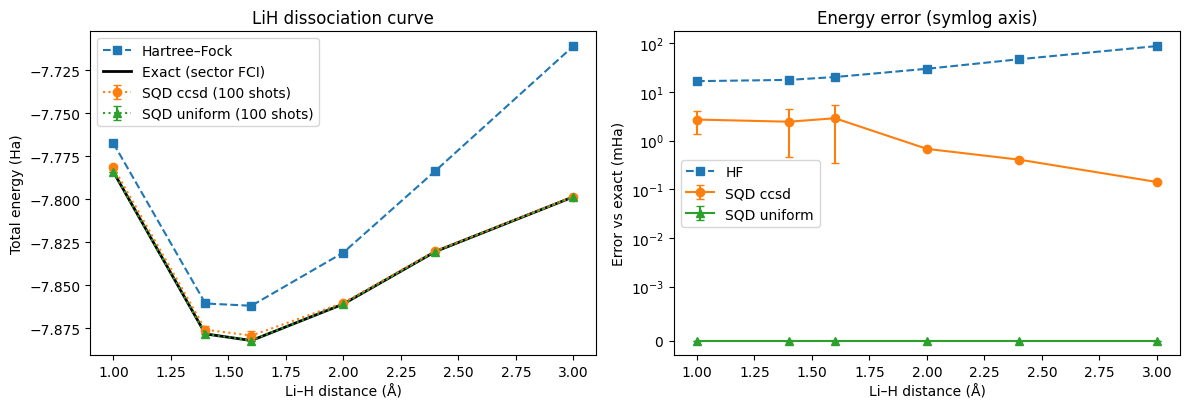

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
Rs = list(PROB)
ax[0].plot(Rs, [PROB[R]["e_hf"] for R in Rs], "s--", label="Hartree–Fock")
ax[0].plot(Rs, [PROB[R]["e_exact"] for R in Rs], "k-", lw=2, label="Exact (sector FCI)")
for m, mk in (("ccsd", "o"), ("uniform", "^")):
    d = sumA[sumA.method == m]; ax[0].errorbar(d.R, d.energy, d.err_std * 1e-3, fmt=mk + ":", label=f"SQD {m} ({SHOTS_A} shots)", capsize=3)
ax[0].set(xlabel="Li–H distance (Å)", ylabel="Total energy (Ha)", title="LiH dissociation curve"); ax[0].legend()
ax[1].plot(Rs, [(PROB[R]["e_hf"] - PROB[R]["e_exact"]) * MHA for R in Rs], "s--", label="HF")
for m, mk in (("ccsd", "o"), ("uniform", "^")):
    d = sumA[sumA.method == m]; ax[1].errorbar(d.R, d.err_mean + 1e-6, d.err_std, fmt=mk + "-", label=f"SQD {m}", capsize=3)
ax[1].set(xlabel="Li–H distance (Å)", ylabel="Error vs exact (mHa)", title="Energy error (symlog axis)"); ax[1].set_yscale("symlog", linthresh=1e-3); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 5 — Budget study at a fixed geometry

Geometry: **R = 2.4 Å** (stretched, strongest correlation). Two resource variables, other settings held fixed:

* **(a) shots** ∈ {5, 10, 30, 100, 300, 1000}; no cap on strings. Full sector = 25 determinants (5 strings).
* **(b) retained subspace size** `max_strings` ∈ {1, 2, 3, 4, 5} at 1000 shots (dimension 1, 4, 9, 16, 25).

Five seeds each. Independent seeds are *not nested*, so the error need not decrease monotonically with shots.

In [10]:
R0 = 2.4; p0 = PROB[R0]; x0 = ccsd_params(p0)
rowsB = []
for shots in [5, 10, 30, 100, 300, 1000]:
    rowsB += run_trials(p0, "ccsd", x0, shots); rowsB += run_trials(p0, "uniform", None, shots)
dfB = pd.DataFrame(rowsB)
def agg(df, by):
    return df.groupby(by).agg(err_mean=("err_mHa", "mean"), err_std=("err_mHa", "std"), err_max=("err_mHa", "max"),
        distinct_mean=("distinct_full", "mean"), distinct_std=("distinct_full", "std"),
        dim_mean=("dim", "mean"), dim_std=("dim", "std")).round(4)
print("(a) error vs shots, R = 2.4 Å (HF error = %.3f mHa)" % ((p0["e_hf"] - p0["e_exact"]) * MHA))
aggB = agg(dfB, ["shots", "method"]); display(aggB)

rowsC = []
for k in [1, 2, 3, 4, 5]:
    rowsC += [dict(r, max_strings=k) for r in run_trials(p0, "ccsd", x0, 1000, max_strings=k)]
    rowsC += [dict(r, max_strings=k) for r in run_trials(p0, "uniform", None, 1000, max_strings=k)]
dfC = pd.DataFrame(rowsC)
print("(b) error vs retained subspace size, 1000 shots"); aggC = agg(dfC, ["max_strings", "method"]); display(aggC)

(a) error vs shots, R = 2.4 Å (HF error = 46.961 mHa)


err_mean   err_std   err_max  distinct_mean  distinct_std  \
shots method                                                               
5     ccsd      31.9335   21.5363   46.9613            1.6        0.8944   
      uniform  164.6359  197.8401  383.1145            4.2        0.8367   
10    ccsd      27.9528   25.1591   46.9613            2.0        1.0000   
      uniform    0.0000    0.0000    0.0000            8.2        1.3038   
30    ccsd       9.3306   19.9562   45.0293            3.4        0.8944   
      uniform    0.0000    0.0000    0.0000           18.0        1.8708   
100   ccsd       0.4059    0.0000    0.4059            6.6        0.8944   
      uniform    0.0000    0.0000    0.0000           24.8        0.4472   
300   ccsd       0.3237    0.1127    0.4059            7.2        0.8367   
      uniform    0.0000    0.0000    0.0000           25.0        0.0000   
1000  ccsd       0.2425    0.1702    0.4059            8.2        0.8367   
      uniform    0.0000    0.0000    0.0000           25.0        0.0000   

               dim_mean  dim_std  
shots method                      
5     ccsd          3.2   3.4928  
      uniform      15.0   6.5955  
10    ccsd          4.8   4.0249  
      uniform      25.0   0.0000  
30    ccsd          8.0   2.2361  
      uniform      25.0   0.0000  
100   ccsd          9.0   0.0000  
      uniform      25.0   0.0000  
300   ccsd         11.8   3.8341  
      uniform      25.0   0.0000  
1000  ccsd         15.0   6.5955  
      uniform      25.0   0.0000

(b) error vs retained subspace size, 1000 shots


err_mean   err_std   err_max  distinct_mean  \
max_strings method                                                 
1           ccsd      46.9613    0.0000   46.9613            8.2   
            uniform  613.8766   32.5535  647.0859           25.0   
2           ccsd      18.3777    0.0000   18.3777            8.2   
            uniform  403.6949  209.4358  531.8839           25.0   
3           ccsd       0.4059    0.0000    0.4059            8.2   
            uniform  268.5778  233.3199  531.8839           25.0   
4           ccsd       0.2825    0.1127    0.4059            8.2   
            uniform   17.6136   23.8443   43.7338           25.0   
5           ccsd       0.2425    0.1702    0.4059            8.2   
            uniform    0.0000    0.0000    0.0000           25.0   

                     distinct_std  dim_mean  dim_std  
max_strings method                                    
1           ccsd           0.8367       1.0   0.0000  
            uniform        0.0000       1.0   0.0000  
2           ccsd           0.8367       4.0   0.0000  
            uniform        0.0000       4.0   0.0000  
3           ccsd           0.8367       9.0   0.0000  
            uniform        0.0000       9.0   0.0000  
4           ccsd           0.8367      13.2   3.8341  
            uniform        0.0000      16.0   0.0000  
5           ccsd           0.8367      15.0   6.5955  
            uniform        0.0000      25.0   0.0000

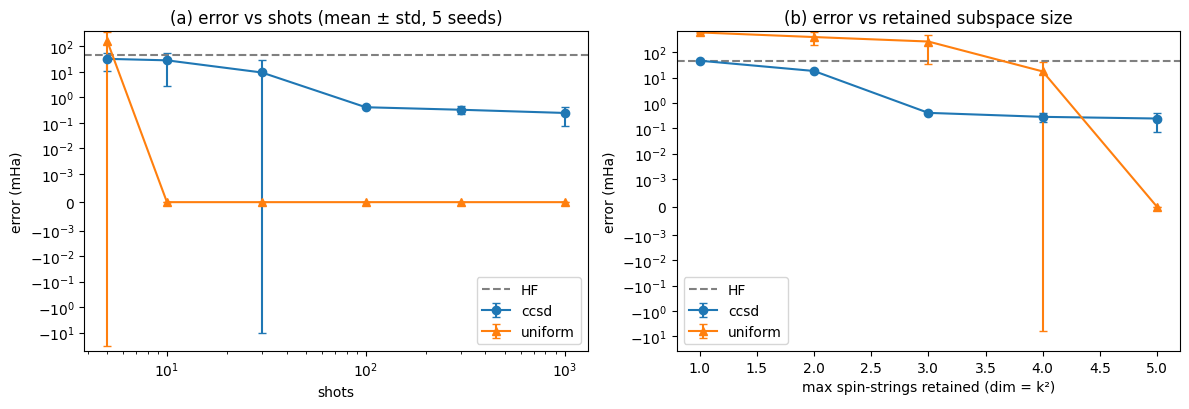

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for m, mk in (("ccsd", "o"), ("uniform", "^")):
    d = aggB.xs(m, level="method"); ax[0].errorbar(d.index, d.err_mean + 1e-6, d.err_std, fmt=mk + "-", capsize=3, label=m)
    d = aggC.xs(m, level="method"); ax[1].errorbar(d.index, d.err_mean + 1e-6, d.err_std, fmt=mk + "-", capsize=3, label=m)
ax[0].axhline((p0["e_hf"] - p0["e_exact"]) * MHA, ls="--", c="gray", label="HF")
ax[1].axhline((p0["e_hf"] - p0["e_exact"]) * MHA, ls="--", c="gray", label="HF")
ax[0].set(xscale="log", xlabel="shots", ylabel="error (mHa)", title="(a) error vs shots (mean ± std, 5 seeds)")
ax[1].set(xlabel="max spin-strings retained (dim = k²)", ylabel="error (mHa)", title="(b) error vs retained subspace size")
ax[0].set_yscale("symlog", linthresh=1e-3); ax[1].set_yscale("symlog", linthresh=1e-3)
ax[0].legend(); ax[1].legend(); plt.tight_layout(); plt.show()

## Step 6 — VQE (optional comparison)

### Physics
VQE minimises $E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)|H|\psi(\boldsymbol\theta)\rangle$ over the same UCCSD circuit (24 parameters), starting from $\boldsymbol\theta=0$ (the HF state). The variational principle guarantees $E(\boldsymbol\theta)\ge E_{\rm exact}$ within the particle sector, and UCCSD preserves the particle number.

### Cost accounting (read carefully)
* To keep Colab runtime small, the optimiser uses an **exact, shot-free statevector** expectation value ("ideal VQE"). This is *not* a finite-shot result. We therefore report the **number of energy evaluations**, the number of **commuting Pauli measurement groups** and a **hypothetical shot cost** if each evaluation were estimated with 1000 shots per group.
* The optimiser is COBYLA, no gradient. Cost of classical optimisation is the wall time and function-evaluation count.

In [12]:
groups = PROB[1.6]["Hq"].group_commuting(qubit_wise=True)
N_GROUPS = len(groups); SHOTS_PER_GROUP = 1000
print("Pauli terms:", len(PROB[1.6]["Hq"]), "| qubit-wise commuting groups:", N_GROUPS)

VQE = {}
for R, p in PROB.items():
    nfev = [0]
    def f(x):
        nfev[0] += 1; return energy_exact_sv(p, x)
    t0 = time.perf_counter()
    res = minimize(f, np.zeros(ans.num_parameters), method="COBYLA", options=dict(maxiter=3000, rhobeg=0.1, tol=1e-9))
    dt = time.perf_counter() - t0
    VQE[R] = dict(x=res.x, energy=res.fun, nfev=nfev[0], seconds=dt)
    log("vqe_optimise", R=R, evals=nfev[0], seconds=dt, hypothetical_shots=nfev[0] * N_GROUPS * SHOTS_PER_GROUP)

tabV = pd.DataFrame([{"R (Å)": R, "E_VQE (Ha)": v["energy"], "VQE err (mHa)": (v["energy"] - PROB[R]["e_exact"]) * MHA,
                      "CCSD-circuit err (mHa)": (energy_exact_sv(PROB[R], ccsd_params(PROB[R])) - PROB[R]["e_exact"]) * MHA,
                      "HF err (mHa)": (PROB[R]["e_hf"] - PROB[R]["e_exact"]) * MHA,
                      "energy evals": v["nfev"], "opt. time (s)": v["seconds"],
                      "hypothetical shots": v["nfev"] * N_GROUPS * SHOTS_PER_GROUP} for R, v in VQE.items()])
tabV.round(5)

Pauli terms: 276 | qubit-wise commuting groups: 58


,R (Å),E_VQE (Ha),VQE err (mHa),CCSD-circuit err (mHa),HF err (mHa),energy evals,opt. time (s),hypothetical shots
0,1.0,-7.78402,0.0,1.33817,16.65918,1085,36.38614,62930000
1,1.4,-7.87823,0.0,1.75609,17.69199,1258,42.65292,72964000
2,1.6,-7.88210,0.0,2.27235,20.23183,1133,40.94502,65714000
3,2.0,-7.86083,0.0,5.03813,29.92267,1396,49.22426,80968000
4,2.4,-7.83034,0.0,14.39274,46.96133,1810,65.74381,104980000
5,3.0,-7.79850,0.0,52.73769,87.67432,3000,107.87493,174000000


## Step 7 — Controlled design test: which trial circuit proposes the configurations?

**Isolated choice:** the *parameters* of the same UCCSD circuit (same depth, same gates, same shots, same subspace rule), evaluated at R = 2.4 Å, 100 shots, 5 seeds:

1. **CCSD-seeded** – classical amplitudes, no optimisation.
2. **VQE-trained** – parameters from Step 6 (adds the optimisation cost).
3. **Random-angle** – θ ~ U(−π, π), a "scrambling" control that carries no chemistry.
4. **Uniform** – no circuit; uniform over valid configurations (Step 4 baseline).

This asks: *does chemistry-informed sampling concentrate on the important determinants, and is that the same as covering the sector?*

In [13]:
rng = np.random.default_rng(123)
x_rand = rng.uniform(-np.pi, np.pi, ans.num_parameters)
variants = {"CCSD-seeded": ("ccsd", x0), "VQE-trained": ("vqe", VQE[R0]["x"]), "random-angle": ("rand", x_rand)}
rowsD = []
for name, (tag, x) in variants.items():
    for shots in (30, 100):
        for s in SEEDS:
            cnts = sample_counts((tag, R0), x, shots, s); r = sqd_solve(cnts, p0)
            rowsD.append(dict(circuit=name, shots=shots, seed=s, err_mHa=(r["energy"] - p0["e_exact"]) * MHA,
                              distinct_full=r["distinct_full"], dim=r["dim"], pop_HF=cnts.get("0000100001", 0) / shots))
for shots in (30, 100):
    for s in SEEDS:
        r = sqd_solve(uniform_counts(shots, 1000 + s), p0)
        rowsD.append(dict(circuit="uniform (no circuit)", shots=shots, seed=s, err_mHa=(r["energy"] - p0["e_exact"]) * MHA,
                          distinct_full=r["distinct_full"], dim=r["dim"], pop_HF=np.nan))
dfD = pd.DataFrame(rowsD)
aggD = dfD.groupby(["shots", "circuit"]).agg(err_mean=("err_mHa", "mean"), err_std=("err_mHa", "std"),
        distinct=("distinct_full", "mean"), dim=("dim", "mean"), HF_weight=("pop_HF", "mean")).round(4)
display(aggD)
print("Exact-state weight of the HF determinant in each trial state (for interpretation):")
for name, (tag, x) in variants.items():
    psi = fast_state(x); pr = np.abs(psi) ** 2
    print(f"  {name:13s} P(HF) = {pr[(1 << NORB) | 1]:.4f}   <H> err = {(energy_exact_sv(p0, x) - p0['e_exact']) * MHA:8.4f} mHa")

err_mean   err_std  distinct   dim  HF_weight
shots circuit                                                            
30    CCSD-seeded             9.3306   19.9562       3.4   8.0     0.8933
      VQE-trained             9.3306   19.9562       3.4   8.0     0.8933
      random-angle          378.2014    0.0000       5.0  16.0     0.0000
      uniform (no circuit)    0.0000    0.0000      18.0  25.0        NaN
100   CCSD-seeded             0.4059    0.0000       6.6   9.0     0.8720
      VQE-trained             0.4059    0.0000       6.2   9.0     0.8780
      random-angle          302.5611  169.1368       7.8  17.8     0.0000
      uniform (no circuit)    0.0000    0.0000      24.8  25.0        NaN

Exact-state weight of the HF determinant in each trial state (for interpretation):
  CCSD-seeded   P(HF) = 0.8809   <H> err =  14.3927 mHa
  VQE-trained   P(HF) = 0.8878   <H> err =   0.0000 mHa
  random-angle  P(HF) = 0.0000   <H> err = 586.7124 mHa


## Step 8 — Total cost ledger

Everything that was run is in `LEDGER`: classical CCSD preprocessing, transpilation, every sampling batch (and its seed), every projected solve, and the VQE optimisation. Circuit metrics are for the **compiled `{cx, rz, sx, x}` circuits**.

In [14]:
L = pd.DataFrame(LEDGER)
summary = L.groupby("stage").agg(calls=("stage", "size"), seconds=("seconds", "sum"),
                                 shots=("shots", "sum"), evals=("evals", "sum")).fillna(0)
display(summary.round(3))
tr = L[L.stage == "transpile"][["key", "qubits", "depth", "two_qubit", "total_gates"]].drop_duplicates("key")
print("Compiled-circuit metrics (examples):"); display(tr.head(8))
print("Total circuit shots (SQD sampling, simulator):", int(L.shots.fillna(0).sum()))
print("Total hypothetical shots if VQE were run on a QPU:", int(L.hypothetical_shots.fillna(0).sum()))

,calls,seconds,shots,evals
stage,,,,
classical_CCSD,6,4.314,0.0,0.0
sample_circuit,117,8.242,38475.0,0.0
sqd_solve,211,4.607,0.0,0.0
transpile,8,0.824,0.0,0.0
vqe_optimise,6,342.827,0.0,9682.0


Compiled-circuit metrics (examples):


,key,qubits,depth,two_qubit,total_gates
6,"('ccsd', 1.6)",10.0,730.0,576.0,1005.0
8,"('ccsd', 2.4)",10.0,730.0,576.0,1005.0
11,"('ccsd', 1.0)",10.0,730.0,576.0,1005.0
27,"('ccsd', 1.4)",10.0,730.0,576.0,1005.0
58,"('ccsd', 2.0)",10.0,730.0,576.0,1005.0
89,"('ccsd', 3.0)",10.0,730.0,576.0,1005.0
296,"('vqe', 2.4)",10.0,1940.0,1520.0,2601.0
317,"('rand', 2.4)",10.0,1940.0,1520.0,2601.0


Total circuit shots (SQD sampling, simulator): 38475
Total hypothetical shots if VQE were run on a QPU: 561556000


## Results summary (seeds 0–4 as in this notebook; numbers are from our reference run)

**Reference values.** HF error grows from 16.7 mHa (1.0 Å) to 46.96 mHa (2.4 Å) and 87.7 mHa (3.0 Å): the stretched bond is strongly correlated, so a single determinant fails.

**1. Same shots → uniform baseline wins (saturation).** The valid sector has only 25 determinants (5 spin-strings). A uniform sampler covers all of them after ~10 shots and returns the exact energy (0.000 mHa). The CCSD-seeded circuit puts ~88 % of its weight on the HF determinant (P(HF)=0.88 at 2.4 Å), so it keeps re-sampling the same strings: 6.6 distinct configurations / dim 9 at 100 shots, with error 0.41 mHa at 2.4 Å. At 1.0–1.6 Å the state is even closer to HF and 100 shots often give only ~3 strings, leaving 2–3 mHa errors. This is a **valid negative result for "quantum samples beat random"** on a toy-size sector — it says nothing about quantum advantage.

**2. Same *solve dimension* → CCSD-seeded samples are far more useful.** When the subspace is capped (Step 5b), keeping the 3 most frequent strings (dim 9) gives 0.41 mHa with CCSD-seeded samples vs ≈ 269 mHa for uniform samples (whose "most frequent" strings are arbitrary and usually miss HF). At dim 4: 18.4 mHa vs ≈ 404 mHa. So the circuit is a good **selector** of important configurations; it is a poor **explorer** of the whole space. If the classical solve were the bottleneck (much larger sector), this would be the regime that matters; here the 25×25 solve costs milliseconds, so there is no cost pressure to truncate.

**3. Variability.** Independent runs are not nested, so error is not monotone in shots (e.g. CCSD-seeded: 9.3 ± 20 mHa at 30 shots, 0.41 ± 0 at 100). Errors at low shots are bimodal: either HF-only (46.96 mHa) or a useful subspace.

**4. VQE.** Ideal (shot-free) UCCSD-VQE reaches the exact sector energy to < 10⁻⁵ Ha at every geometry but needs 1.2k–3k energy evaluations per geometry (≈ 10⁸ hypothetical shots with 58 measurement groups × 1000 shots each) and a 1.5–2× deeper compiled circuit; the CCSD-seeded circuit's own <H> is 14 mHa off at 2.4 Å and 53 mHa off at 3.0 Å, yet SQD on its samples is within 0.4 mHa at 2.4 Å, because SQD only needs the right *configurations*, not the right *amplitudes*.

**5. Design test (Step 7).** Same circuit structure, different parameters: CCSD-seeded and VQE-trained circuits give identical SQD accuracy at 30/100 shots (0.41 mHa) — the expensive optimisation buys nothing for configuration selection here. A random-angle circuit scrambles the state (P(HF)≈0) and gives 300–380 mHa errors at the same shots; random angles ≠ uniform sampling, and it is worse than both.

**Conclusion for this experiment.** Best accuracy/cost trade-off: *CCSD-seeded circuit + SQD with a capped subspace* (≈ 0.4 mHa at dim 9, ~100 shots, ~0.3 s total classical CCSD) — it matches VQE-quality energies at a tiny fraction of the optimisation cost. If you can afford the full 25-dimension solve, uniform sampling is as good or better, so no sampling advantage is claimed.

### Caveats worth stating in your README
* Ideal noiseless simulator; no configuration recovery. Compiled depth/2-qubit counts depend on which angles are exactly zero (the transpiler drops symmetry-forbidden near-zero rotations), so the CCSD circuit (depth 730, 576 CX) looks cheaper than VQE/random circuits (depth 1940, 1520 CX); the *logical* ansatz is identical.
* Tiny 25-determinant sector ⇒ saturation; use a larger active space for genuine truncation studies.
* VQE uses exact expectation values; hypothetical shots are an estimate, not a measurement.
* 5 seeds → rough spread only; raise `SEEDS` for the final report.

### Next steps for the challenge repository
Public GitHub repo with this notebook, a `README.md` (problem, setup, run steps, results, limitations), pinned versions (`pip freeze`), saved figures. Then add one extension: a bit-flip/noise model with discard vs `recover_configurations`, or a larger active space (e.g. LiH without freezing the core, or H₂O / N₂).